In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
from PIL import Image
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print('Libraries imported successfully')

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Libraries imported successfully


In [2]:
# Load preprocessed data
print('Loading preprocessed data...')

DATA_PATH = '/kaggle/input/brain-tumor-mri-preprocess-sets/'

# Load train set (augmented)
train_images = np.load(os.path.join(DATA_PATH, 'preprocessed_train_images.npy'), mmap_mode='r')
train_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_train_labels.npy'))

# Load validation set (original, not augmented)
val_images = np.load(os.path.join(DATA_PATH, 'preprocessed_val_images.npy'), mmap_mode='r')
val_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_val_labels.npy'))

# Load test set (original, not augmented)
test_images = np.load(os.path.join(DATA_PATH, 'preprocessed_test_images.npy'), mmap_mode='r')
test_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_test_labels.npy'))

# Load class names
label_classes = np.load(os.path.join(DATA_PATH, 'label_classes.npy'))

print('Preprocessed data loaded successfully!')
print(f'\nTrain set: {len(train_images)} images, shape: {train_images[0].shape}')
print(f'Validation set: {len(val_images)} images, shape: {val_images[0].shape}')
print(f'Test set: {len(test_images)} images, shape: {test_images[0].shape}')

# Check class distribution
print('\nClass distribution:')
print(f'Classes: {label_classes}')

Loading preprocessed data...
Preprocessed data loaded successfully!

Train set: 22845 images, shape: (256, 256, 3)
Validation set: 1143 images, shape: (256, 256, 3)
Test set: 1311 images, shape: (256, 256, 3)

Class distribution:
Classes: ['glioma_tumor' 'meningioma_tumor' 'no_tumor' 'pituitary_tumor']


In [3]:
# Use actual labels from data:
label_classes = np.unique(np.concatenate([train_labels, val_labels, test_labels]))
label_classes = np.sort(label_classes)

print(f'Using actual classes: {label_classes}')

label_encoder = LabelEncoder()
label_encoder.classes_ = label_classes

Using actual classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


In [4]:
# # Create label encoder using the saved classes
# label_encoder = LabelEncoder()
# label_encoder.classes_ = label_classes

# Encode labels (they're already strings from preprocessing)
train_labels_encoded = label_encoder.transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Create label mapping for reference
label_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
print('\nLabel mapping:')
for idx, class_name in label_mapping.items():
    print(f'{idx}: {class_name}')

# Store class names for later use
class_names = label_encoder.classes_
num_classes = len(class_names)
print(f'\nNumber of classes: {num_classes}')


Label mapping:
0: glioma
1: meningioma
2: notumor
3: pituitary

Number of classes: 4


In [5]:
# Verify data distribution (already split in preprocessing)
print('\nTraining set distribution:')
unique, counts = np.unique(train_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')

print('\nValidation set distribution:')
unique, counts = np.unique(val_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')

print('\nTest set distribution:')
unique, counts = np.unique(test_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')


Training set distribution:
glioma: 5285 images
meningioma: 5355 images
notumor: 6380 images
pituitary: 5825 images

Validation set distribution:
glioma: 264 images
meningioma: 268 images
notumor: 319 images
pituitary: 292 images

Test set distribution:
glioma: 300 images
meningioma: 306 images
notumor: 405 images
pituitary: 300 images


In [6]:
class BrainTumorDataset(Dataset):
    """
    Custom dataset that loads images on-the-fly from memory-mapped array
    Images are already preprocessed to 256x256 with gamma correction
    Only needs to resize if model requires different input size
    """
    def __init__(self, images_mmap, labels, input_size=256):
        self.images_mmap = images_mmap
        self.labels = labels
        self.input_size = input_size
        self.needs_resize = (input_size != 256)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Load image from memory-mapped array
        image = self.images_mmap[idx].copy()
        label = self.labels[idx]
        
        # Images are already gamma corrected and in range 0-255
        # Normalize to 0-1
        image = image.astype(np.float32) / 255.0
        
        # Convert BGR to RGB
        image = image[:, :, [2, 1, 0]]
        
        # Resize only if model requires different size
        if self.needs_resize:
            image_pil = Image.fromarray((image * 255).astype(np.uint8))
            image_pil = image_pil.resize((self.input_size, self.input_size), Image.LANCZOS)
            image = np.array(image_pil).astype(np.float32) / 255.0
        
        # Convert to tensor and permute to (C, H, W)
        image_tensor = torch.from_numpy(image).permute(2, 0, 1)
        
        # Apply ImageNet normalization
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_tensor = (image_tensor - mean) / std
        
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        return image_tensor, label_tensor

print('Custom Dataset class defined')

Custom Dataset class defined


In [7]:
INPUT_SIZE = 224

print(f'Creating datasets with input size: {INPUT_SIZE}x{INPUT_SIZE}...')

# Create datasets directly (no indices needed - data already split!)
train_dataset = BrainTumorDataset(train_images, train_labels_encoded, input_size=INPUT_SIZE)
val_dataset = BrainTumorDataset(val_images, val_labels_encoded, input_size=INPUT_SIZE)
test_dataset = BrainTumorDataset(test_images, test_labels_encoded, input_size=INPUT_SIZE)

print('Datasets created successfully')
print(f'Train dataset: {len(train_dataset)} images')
print(f'Val dataset: {len(val_dataset)} images')
print(f'Test dataset: {len(test_dataset)} images')

Creating datasets with input size: 224x224...
Datasets created successfully
Train dataset: 22845 images
Val dataset: 1143 images
Test dataset: 1311 images


In [8]:
# Create dataloaders with very large batch size for TinyViT-5M (smallest model)
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=2, pin_memory=True)

print('DataLoaders created')
print(f'Batch size: {BATCH_SIZE}')
print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

# Test loading one batch
print('\nTesting data loading...')
test_batch = next(iter(train_loader))
print(f'Batch images shape: {test_batch[0].shape}')
print(f'Batch labels shape: {test_batch[1].shape}')
print('Data loading test successful!')

DataLoaders created
Batch size: 128
Training batches: 179
Validation batches: 9
Test batches: 11

Testing data loading...
Batch images shape: torch.Size([128, 3, 224, 224])
Batch labels shape: torch.Size([128])
Data loading test successful!


In [9]:
# Create TinyViT-5M model
print('Creating TinyViT-5M model...')
model = timm.create_model('tiny_vit_5m_224', pretrained=True, num_classes=num_classes)
model = model.to(device)

print('TinyViT-5M model created successfully')
print(f'Model moved to {device}')
print('Using ImageNet-1k pretrained weights')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Creating TinyViT-5M model...


model.safetensors:   0%|          | 0.00/48.4M [00:00<?, ?B/s]

TinyViT-5M model created successfully
Model moved to cuda
Using ImageNet-1k pretrained weights
Total parameters: 5,073,048
Trainable parameters: 5,073,048


In [10]:
# Training hyperparameters for TinyViT with 2-phase training and warmup
WARMUP_EPOCHS = 3
NUM_EPOCHS_PHASE1 = 12
NUM_EPOCHS_PHASE2 = 20
LEARNING_RATE_PHASE1 = 0.001
LEARNING_RATE_PHASE2 = 0.0001
EARLY_STOPPING_PATIENCE = 7

# Loss function
criterion = nn.CrossEntropyLoss()

# Training history
history = {
    'phase': [],
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

# Early stopping setup
best_val_loss = float('inf')
patience_counter = 0
best_model_wts = None

print('Training configuration:')
print(f'Warmup epochs: {WARMUP_EPOCHS}')
print(f'Phase 1 epochs: {NUM_EPOCHS_PHASE1}')
print(f'Phase 2 epochs: {NUM_EPOCHS_PHASE2}')
print(f'Phase 1 learning rate: {LEARNING_RATE_PHASE1}')
print(f'Phase 2 learning rate: {LEARNING_RATE_PHASE2}')
print(f'Early stopping patience: {EARLY_STOPPING_PATIENCE}')
print(f'Batch size: {BATCH_SIZE}')

Training configuration:
Warmup epochs: 3
Phase 1 epochs: 12
Phase 2 epochs: 20
Phase 1 learning rate: 0.001
Phase 2 learning rate: 0.0001
Early stopping patience: 7
Batch size: 128


In [11]:
class WarmupScheduler:
    """
    Learning rate scheduler with warmup for Phase 1
    """
    def __init__(self, optimizer, warmup_epochs, base_lr, total_steps_per_epoch):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.base_lr = base_lr
        self.total_steps_per_epoch = total_steps_per_epoch
        self.current_step = 0
        self.warmup_steps = warmup_epochs * total_steps_per_epoch
    
    def step(self):
        """
        Update learning rate
        """
        self.current_step += 1
        
        if self.current_step < self.warmup_steps:
            # Warmup phase: linear increase
            lr = self.base_lr * self.current_step / self.warmup_steps
        else:
            # After warmup: use base learning rate
            lr = self.base_lr
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        return lr
    
    def get_lr(self):
        """
        Get current learning rate
        """
        return self.optimizer.param_groups[0]['lr']

print('Warmup scheduler defined')

Warmup scheduler defined


In [12]:
def freeze_backbone(model):
    """
    Freeze all layers except the final classifier
    """
    for name, param in model.named_parameters():
        if 'head' not in name and 'classifier' not in name:
            param.requires_grad = False
    
    return model

def unfreeze_all(model):
    """
    Unfreeze all layers for fine-tuning
    """
    for param in model.parameters():
        param.requires_grad = True
    
    return model

def train_epoch(model, train_loader, criterion, optimizer, device, warmup_scheduler=None):
    """
    Train for one epoch
    """
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # Update warmup scheduler if provided
        if warmup_scheduler is not None:
            warmup_scheduler.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    """
    Validate for one epoch
    """
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

print('Training helper functions defined')

Training helper functions defined


In [13]:
print('Starting Phase 1: Training with frozen backbone and warmup')
print(f'Warmup: Epochs 1-{WARMUP_EPOCHS} (LR: 0 -> {LEARNING_RATE_PHASE1})')
print(f'Training: Epochs {WARMUP_EPOCHS+1}-{NUM_EPOCHS_PHASE1+WARMUP_EPOCHS} (LR: {LEARNING_RATE_PHASE1})')
print()

# Freeze backbone
model = freeze_backbone(model)

# Count trainable parameters
trainable_params_phase1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters in Phase 1: {trainable_params_phase1:,}')
print()

# Optimizer and schedulers with lower weight decay for tiny model
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=LEARNING_RATE_PHASE1, weight_decay=0.01)

# Warmup scheduler
warmup_scheduler = WarmupScheduler(optimizer, WARMUP_EPOCHS, LEARNING_RATE_PHASE1, len(train_loader))

# Main scheduler after warmup
main_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                       factor=0.5, patience=3)

# Training loop for Phase 1
total_phase1_epochs = WARMUP_EPOCHS + NUM_EPOCHS_PHASE1

for epoch in range(total_phase1_epochs):
    # Determine if in warmup phase
    in_warmup = (epoch < WARMUP_EPOCHS)
    
    # Train epoch
    if in_warmup:
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, warmup_scheduler)
    else:
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, None)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Step main scheduler after warmup
    if not in_warmup:
        old_lr = current_lr
        main_scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if new_lr != old_lr:
            print(f'Learning rate reduced from {old_lr:.6f} to {new_lr:.6f}')
    
    # Store history
    history['phase'].append(1)
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Print progress
    phase_label = 'Phase 1 (Warmup)' if in_warmup else 'Phase 1'
    print(f'{phase_label} - Epoch {epoch+1}/{total_phase1_epochs}')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'Learning Rate: {current_lr:.6f}')
    
    # Early stopping check (only after warmup)
    if not in_warmup:
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            print('Validation loss improved. Saving model...')
        else:
            patience_counter += 1
            print(f'No improvement in validation loss. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}')
        
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break
    else:
        # During warmup, always save if best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
    
    print()

print('Phase 1 training completed')
print()

Starting Phase 1: Training with frozen backbone and warmup
Warmup: Epochs 1-3 (LR: 0 -> 0.001)
Training: Epochs 4-15 (LR: 0.001)

Trainable parameters in Phase 1: 1,924

Phase 1 (Warmup) - Epoch 1/15
Train Loss: 1.1207, Train Acc: 0.6289
Val Loss: 0.7514, Val Acc: 0.8320
Learning Rate: 0.000333

Phase 1 (Warmup) - Epoch 2/15
Train Loss: 0.5535, Train Acc: 0.8532
Val Loss: 0.4127, Val Acc: 0.8679
Learning Rate: 0.000667

Phase 1 (Warmup) - Epoch 3/15
Train Loss: 0.3447, Train Acc: 0.8891
Val Loss: 0.3061, Val Acc: 0.8828
Learning Rate: 0.001000

Phase 1 - Epoch 4/15
Train Loss: 0.2755, Train Acc: 0.9041
Val Loss: 0.2679, Val Acc: 0.8950
Learning Rate: 0.001000
Validation loss improved. Saving model...

Phase 1 - Epoch 5/15
Train Loss: 0.2409, Train Acc: 0.9137
Val Loss: 0.2493, Val Acc: 0.9073
Learning Rate: 0.001000
Validation loss improved. Saving model...

Phase 1 - Epoch 6/15
Train Loss: 0.2239, Train Acc: 0.9206
Val Loss: 0.2398, Val Acc: 0.9073
Learning Rate: 0.001000
Validation l

In [14]:
print('Starting Phase 2: Fine-tuning entire network')
print(f'Epochs: {NUM_EPOCHS_PHASE2}, Learning Rate: {LEARNING_RATE_PHASE2}')
print()

# Unfreeze all layers
model = unfreeze_all(model)

# Count trainable parameters
trainable_params_phase2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters in Phase 2: {trainable_params_phase2:,}')
print()

# New optimizer and scheduler for Phase 2 with lower weight decay
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE_PHASE2, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                   factor=0.5, patience=3)

# Get number of epochs completed in Phase 1
phase1_epochs = len([x for x in history['phase'] if x == 1])

# Training loop for Phase 2
for epoch in range(NUM_EPOCHS_PHASE2):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, None)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Step scheduler
    old_lr = current_lr
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    if new_lr != old_lr:
        print(f'Learning rate reduced from {old_lr:.6f} to {new_lr:.6f}')
    
    # Store history
    history['phase'].append(2)
    history['epoch'].append(phase1_epochs + epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(new_lr)
    
    print(f'Phase 2 - Epoch {epoch+1}/{NUM_EPOCHS_PHASE2} (Total: {phase1_epochs + epoch + 1})')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'Learning Rate: {new_lr:.6f}')
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_wts = copy.deepcopy(model.state_dict())
        print('Validation loss improved. Saving model...')
    else:
        patience_counter += 1
        print(f'No improvement in validation loss. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}')
    
    print()
    
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping triggered at epoch {phase1_epochs + epoch + 1}')
        break

# Load best model weights
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print('Loaded best model weights')

print('Training completed')

Starting Phase 2: Fine-tuning entire network
Epochs: 20, Learning Rate: 0.0001

Trainable parameters in Phase 2: 5,073,048

Phase 2 - Epoch 1/20 (Total: 16)
Train Loss: 0.0790, Train Acc: 0.9713
Val Loss: 0.0801, Val Acc: 0.9729
Learning Rate: 0.000100
Validation loss improved. Saving model...

Phase 2 - Epoch 2/20 (Total: 17)
Train Loss: 0.0108, Train Acc: 0.9978
Val Loss: 0.2197, Val Acc: 0.9291
Learning Rate: 0.000100
No improvement in validation loss. Patience: 1/7

Phase 2 - Epoch 3/20 (Total: 18)
Train Loss: 0.0036, Train Acc: 0.9996
Val Loss: 0.0904, Val Acc: 0.9720
Learning Rate: 0.000100
No improvement in validation loss. Patience: 2/7

Phase 2 - Epoch 4/20 (Total: 19)
Train Loss: 0.0014, Train Acc: 1.0000
Val Loss: 0.0704, Val Acc: 0.9799
Learning Rate: 0.000100
Validation loss improved. Saving model...

Phase 2 - Epoch 5/20 (Total: 20)
Train Loss: 0.0008, Train Acc: 0.9999
Val Loss: 0.0788, Val Acc: 0.9816
Learning Rate: 0.000100
No improvement in validation loss. Patience: 

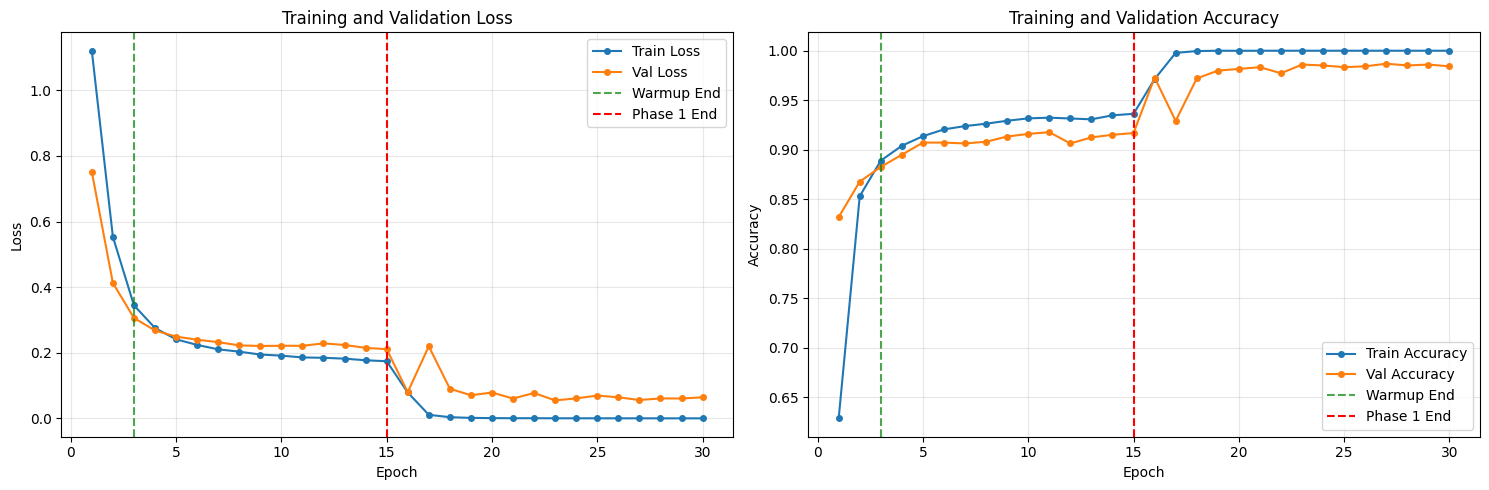

Training history plotted and saved


In [15]:
# Convert history to DataFrame
history_df = pd.DataFrame(history)

# Create training history plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='o', markersize=4)

# Add vertical lines at phase boundaries
warmup_end = WARMUP_EPOCHS
phase1_end = len([x for x in history['phase'] if x == 1])
axes[0].axvline(x=warmup_end, color='g', linestyle='--', label='Warmup End', alpha=0.7)
axes[0].axvline(x=phase1_end, color='r', linestyle='--', label='Phase 1 End')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Train Accuracy', marker='o', markersize=4)
axes[1].plot(history_df['epoch'], history_df['val_acc'], label='Val Accuracy', marker='o', markersize=4)
axes[1].axvline(x=warmup_end, color='g', linestyle='--', label='Warmup End', alpha=0.7)
axes[1].axvline(x=phase1_end, color='r', linestyle='--', label='Phase 1 End')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tinyvit_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print('Training history plotted and saved')

In [16]:
def evaluate_model(model, test_loader, device):
    """
    Evaluate model on test set and return predictions and labels
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Get predictions on test set
print('Evaluating model on test set...')
test_preds, test_labels_array, test_probs = evaluate_model(model, test_loader, device)

# Calculate metrics
test_accuracy = accuracy_score(test_labels_array, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels_array, test_preds, average='weighted')

print('Test Set Results:')
print(f'Accuracy: {test_accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print()

# Per-class metrics
print('Per-Class Metrics:')
class_report = classification_report(test_labels_array, test_preds, target_names=class_names, digits=4)
print(class_report)

Evaluating model on test set...
Test Set Results:
Accuracy: 0.9886
Precision: 0.9886
Recall: 0.9886
F1-Score: 0.9886

Per-Class Metrics:
              precision    recall  f1-score   support

      glioma     0.9900    0.9867    0.9883       300
  meningioma     0.9770    0.9739    0.9755       306
     notumor     0.9975    0.9951    0.9963       405
   pituitary     0.9868    0.9967    0.9917       300

    accuracy                         0.9886      1311
   macro avg     0.9878    0.9881    0.9879      1311
weighted avg     0.9886    0.9886    0.9886      1311



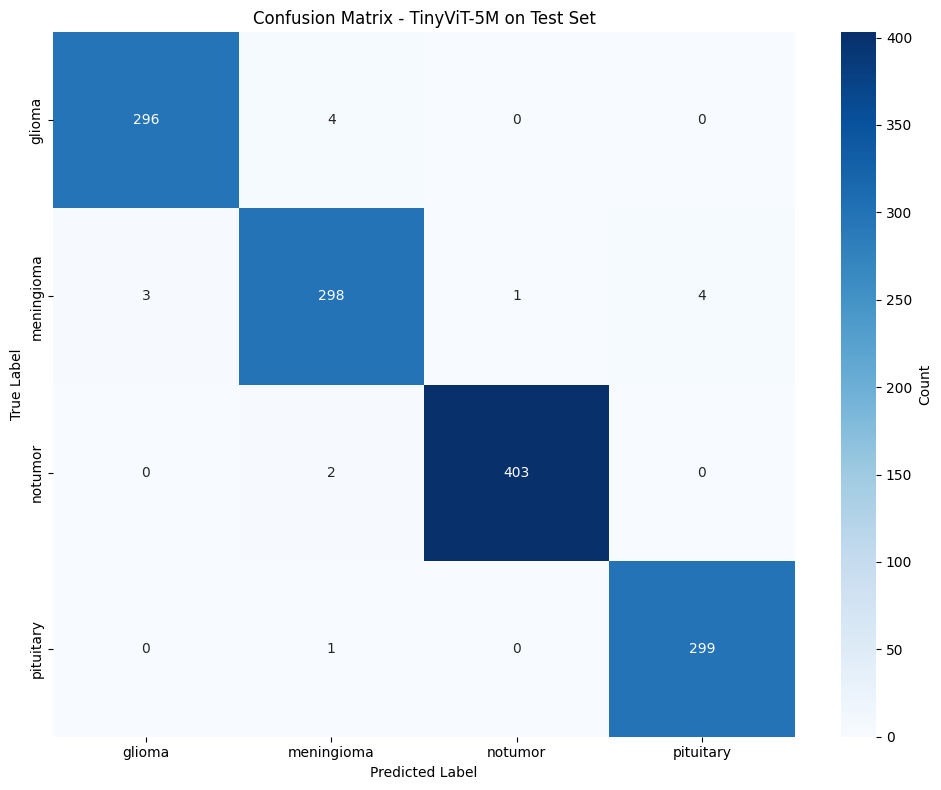

Per-Class Accuracy:
glioma: 0.9867
meningioma: 0.9739
notumor: 0.9951
pituitary: 0.9967


In [17]:
# Calculate confusion matrix
cm = confusion_matrix(test_labels_array, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - TinyViT-5M on Test Set')
plt.tight_layout()
plt.savefig('tinyvit_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print('Per-Class Accuracy:')
for i, class_name in enumerate(class_names):
    print(f'{class_name}: {per_class_acc[i]:.4f}')

In [18]:
pip install thop

Note: you may need to restart the kernel to use updated packages.


In [19]:
from thop import profile

def calculate_efficiency_metrics(model, device, input_size=(1, 3, 224, 224)):
    """
    Calculate comprehensive efficiency metrics
    """
    model.eval()
    
    # Total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Model size in MB
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    # FLOPs calculation
    dummy_input = torch.randn(input_size).to(device)
    flops, params_thop = profile(model, inputs=(dummy_input,), verbose=False)
    flops_gflops = flops / 1e9
    
    # Inference time and FPS
    num_warmup = 10
    num_iterations = 100
    
    # Warmup
    with torch.no_grad():
        for _ in range(num_warmup):
            _ = model(dummy_input)
    
    # Synchronize GPU
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    # Measure inference time
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    end_time = time.time()
    
    avg_time_per_image = ((end_time - start_time) / num_iterations) * 1000
    fps = 1000 / avg_time_per_image
    
    # GPU memory usage
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        
        with torch.no_grad():
            _ = model(dummy_input)
        
        gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        gpu_memory_mb = 0
    
    metrics = {
        'Total Parameters': total_params,
        'Trainable Parameters': trainable_params,
        'Model Size (MB)': model_size_mb,
        'FLOPs (GFLOPs)': flops_gflops,
        'Inference Time (ms)': avg_time_per_image,
        'FPS': fps,
        'GPU Memory (MB)': gpu_memory_mb
    }
    
    return metrics

# Calculate efficiency metrics
print('Calculating efficiency metrics...')
efficiency_metrics = calculate_efficiency_metrics(model, device, input_size=(1, 3, INPUT_SIZE, INPUT_SIZE))

print('\nEfficiency Metrics:')
print(f"Total Parameters: {efficiency_metrics['Total Parameters']:,}")
print(f"Trainable Parameters: {efficiency_metrics['Trainable Parameters']:,}")
print(f"Model Size: {efficiency_metrics['Model Size (MB)']:.2f} MB")
print(f"FLOPs: {efficiency_metrics['FLOPs (GFLOPs)']:.2f} GFLOPs")
print(f"Inference Time: {efficiency_metrics['Inference Time (ms)']:.2f} ms per image")
print(f"FPS: {efficiency_metrics['FPS']:.2f}")
print(f"GPU Memory Usage: {efficiency_metrics['GPU Memory (MB)']:.2f} MB")

Calculating efficiency metrics...

Efficiency Metrics:
Total Parameters: 5,073,048
Trainable Parameters: 5,073,048
Model Size: 21.22 MB
FLOPs: 1.18 GFLOPs
Inference Time: 8.34 ms per image
FPS: 119.86
GPU Memory Usage: 133.70 MB


In [20]:
# Create results dictionary
results = {
    'model_name': 'TinyViT-5M',
    'pretrained_weights': 'ImageNet-1k',
    'test_accuracy': test_accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'per_class_accuracy': {class_names[i]: per_class_acc[i] for i in range(len(class_names))},
    **efficiency_metrics
}

# Save results to CSV
results_df = pd.DataFrame([results])
results_df.to_csv('tinyvit_results.csv', index=False)
print('Results saved to tinyvit_results.csv')

# Save training history
history_df.to_csv('tinyvit_training_history.csv', index=False)
print('Training history saved to tinyvit_training_history.csv')

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'label_encoder': label_encoder,
    'results': results,
    'history': history
}, 'tinyvit_brain_tumor_model.pth')
print('Model saved to tinyvit_brain_tumor_model.pth')

print('\nAll results and model saved successfully')

Results saved to tinyvit_results.csv
Training history saved to tinyvit_training_history.csv
Model saved to tinyvit_brain_tumor_model.pth

All results and model saved successfully


In [21]:
# Create comprehensive summary table for thesis
summary_data = {
    'Metric': [
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'Total Parameters',
        'Model Size (MB)',
        'FLOPs (GFLOPs)',
        'Inference Time (ms)',
        'FPS',
        'GPU Memory (MB)'
    ],
    'Value': [
        f'{test_accuracy:.4f}',
        f'{precision:.4f}',
        f'{recall:.4f}',
        f'{f1:.4f}',
        f"{efficiency_metrics['Total Parameters']:,}",
        f"{efficiency_metrics['Model Size (MB)']:.2f}",
        f"{efficiency_metrics['FLOPs (GFLOPs)']:.2f}",
        f"{efficiency_metrics['Inference Time (ms)']:.2f}",
        f"{efficiency_metrics['FPS']:.2f}",
        f"{efficiency_metrics['GPU Memory (MB)']:.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print('TinyViT-5M Summary for Thesis:')
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('tinyvit_summary_table.csv', index=False)
print('\nSummary table saved to tinyvit_summary_table.csv')

TinyViT-5M Summary for Thesis:
             Metric     Value
      Test Accuracy    0.9886
          Precision    0.9886
             Recall    0.9886
           F1-Score    0.9886
   Total Parameters 5,073,048
    Model Size (MB)     21.22
     FLOPs (GFLOPs)      1.18
Inference Time (ms)      8.34
                FPS    119.86
    GPU Memory (MB)    133.70

Summary table saved to tinyvit_summary_table.csv
